# Diabetes Prediction Dataset

**Description:**

Welcome to the **Diabetes Prediction Dataset**, a valuable resource for researchers, data scientists, and medical professionals interested in the field of diabetes risk assessment and prediction. This dataset contains a diverse range of health-related attributes, meticulously collected to aid in the development of predictive models for identifying individuals at risk of diabetes. By sharing this dataset, we aim to foster collaboration and innovation within the data science community, leading to improved early diagnosis and personalized treatment strategies for diabetes. This dataset is a clinical collection of 1,000 patient records sourced from Medical City Hospital and Al-Kindy Teaching Hospital. It bridges demographic data with intensive metabolic markers.

**Column groups:**

- **Demographic:** Age, Gender
- **Renal Markers:** Creatinine ratio (Cr), Urea
- **Lipid Profile:** Cholesterol (Chol), LDL, VLDL, Triglycerides (TG), HDL
- **Glucose Control:** HBA1C
- **Body Composition:** Body Mass Index (BMI)
- **Target Class:** Diabetic (Y), Non-Diabetic (N), Pre-Diabetic (P)





In [1]:
import seaborn as sns # for making plots
import matplotlib.pyplot as plt # for making plots
from sklearn.model_selection import train_test_split # for splitting our data into train and test set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # for evaluating the performance of the model
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv("/content/drive/MyDrive/Jobs/Mr Dayo/DIABETES PREDICTION/Diabetes.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


## Basic Data Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [5]:
df.shape

(1000, 14)

In [6]:
df = df.drop(['ID', 'No_Pation'], axis=1)
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [7]:
df['CLASS'] = df['CLASS'].str.strip()
df['Gender'] = df['Gender'].str.strip().str.upper()

In [8]:
df.CLASS.value_counts()

,count
CLASS,
Y,844
N,103
P,53


In [9]:
df.CLASS.value_counts()/df.shape[0]*100

,count
CLASS,
Y,84.4
N,10.3
P,5.3


## Five Number Summary

In [10]:
df.describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


Here is the breakdown of what the table above is telling us:

### 1. Key Clinical Indicators
* **HbA1c (The Gold Standard):** the mean is **8.28%**, with a median (50%) of **8.0%**. In clinical terms, anything above **6.5%** is typically diagnosed as diabetic. Since 75% of the data is above **6.5%**, this confirms why the "Y" class is so dominant (84%).
* **Age:** The average patient is about **53 years old**. The distribution is quite tight (standard deviation of ~8.8), with most patients falling between **45 and 62**. This suggests the model will be highly specialized for middle-aged to elderly populations.
* **BMI:** The mean BMI is **29.58**, which is right on the border of "Overweight" and "Obese." The max value of **47.75** indicates some cases of severe obesity in the dataset.



### 2. Detection of Outliers (The "Red Flags")
When looking at the `max` column vs. the `75%` column, we see some extreme jumps that indicate outliers:

| Feature | 75th Percentile | Max Value | Observation |
| :--- | :--- | :--- | :--- |
| **Cr (Creatinine)** | 73.0 | **800.0** | Huge jump. 800 is extremely high (suggesting severe kidney failure). |
| **Urea** | 5.7 | **38.9** | Another renal marker showing extreme outliers. |
| **TG (Triglycerides)**| 1.5 | **13.8** | Significant spikes in blood fat levels. |
| **VLDL** | 1.5 | **35.0** | This is a massive outlier compared to the mean of 1.85. |



### 3. Data Distribution & Skewness
* **Lipid Profile (Chol, TG, LDL, HDL):** These appear relatively "normal" in their spread, though the **HDL** (the "good" cholesterol) has a mean of **1.2**, which is within a standard healthy range, though the min of **0.2** is dangerously low.
* **Symmetry:** For most variables, the **Mean** and **Median (50%)** are close (e.g., Age 53 vs 55), which suggests those specific features are somewhat normally distributed. However, **Cr** and **Urea** are "right-skewed" due to those high maximum values.


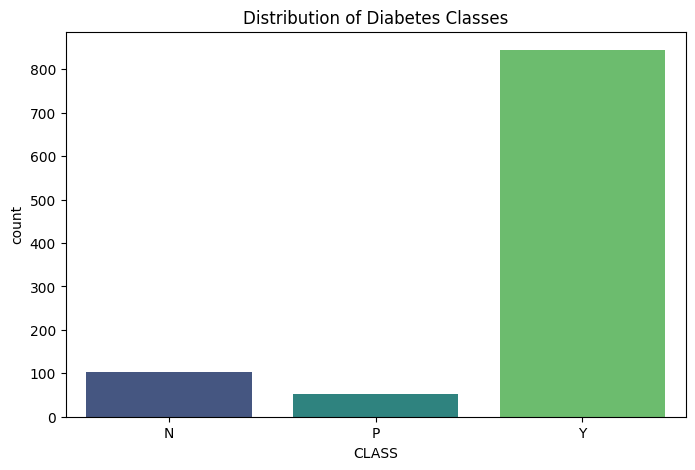

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x='CLASS', data=df, palette='viridis')
plt.title('Distribution of Diabetes Classes')
plt.show()

Y represents the people that are Diabetic, N represents the people that are Non-Diabetic, while P represent the people that are Pre-Diabetic.
And as we can see here, we have an umbalanced dataset. this could affect our model's ability to make predictions. we need to balance the data.

In [12]:
df.isnull().sum()

,0
Gender,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0
HDL,0
LDL,0
VLDL,0


In [13]:
df.duplicated().sum()

np.int64(174)

In [14]:
df = df.drop_duplicates()
df.shape

(826, 12)

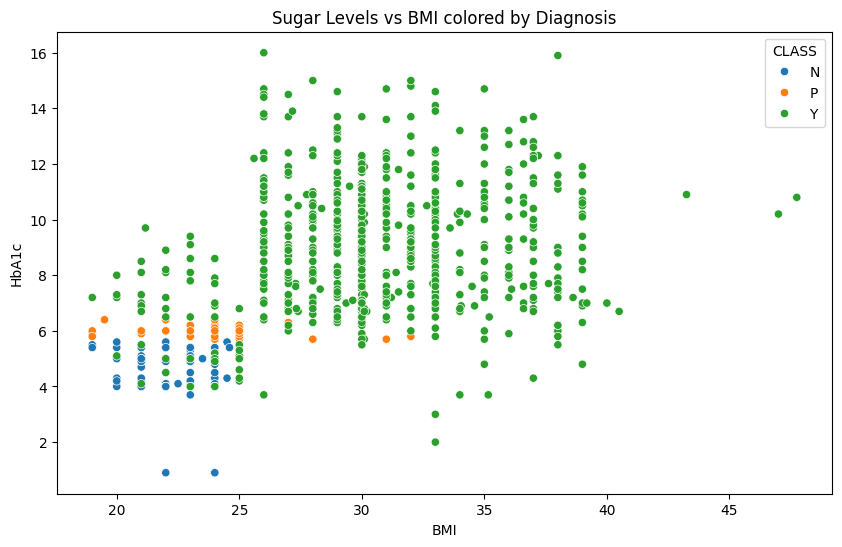

In [15]:
# 4. BMI vs Sugar Level by Class
plt.figure(figsize=(10, 6))
sns.scatterplot(x='BMI', y='HbA1c', hue='CLASS', data=df)
plt.title('Sugar Levels vs BMI colored by Diagnosis')
plt.show()

This further confirms our finding from the statistical analysis table above that patients with higher HbA1c levels are more at the risk of being diabetic.

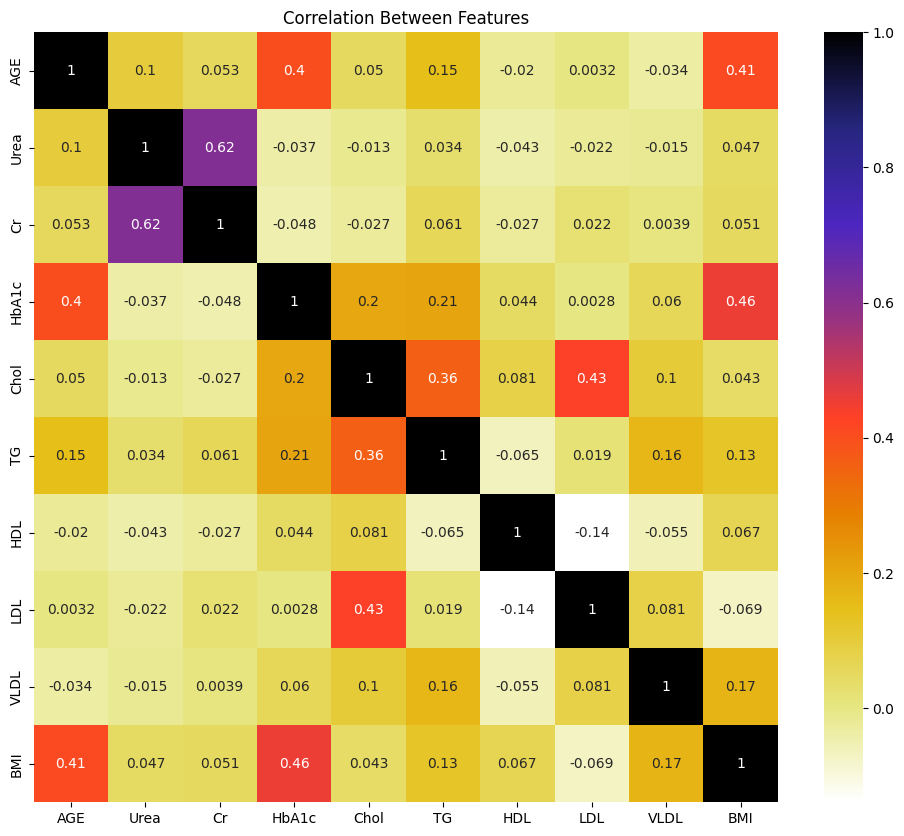

In [16]:
plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True,cmap=plt.cm.CMRmap_r)
plt.title('Correlation Between Features')
plt.show();

The matrix is revealing some very distinct "groupings", we look for these relationships because they help us understand which features "move together."

Here are the three most significant takeaways:

* **The "Metabolic Cluster" (Age, BMI, HbA1c):**
    There is a moderate-to-strong positive correlation between **BMI and HbA1c (0.45)** and **Age and HbA1c (0.40)**. This confirms that in this specific dataset, higher body mass and age are significant drivers of long-term blood sugar levels.
* **The "Renal Cluster" (Urea and Cr):**
    There is a strong correlation between **Urea and Creatinine (0.61)**. This is expected medically, as both are markers of kidney function. Interestingly, these renal markers have almost **zero correlation** with HbA1c, suggesting that in this group, kidney issues might be independent of how well their diabetes is managed.
* **Lipid Relationships:**
    **Cholesterol and LDL (0.43)** show a moderate link, which is standard. However, **HDL (the "good" cholesterol)** shows negative or near-zero correlations with almost everything else, which is typical for its role as a scavenger molecule.


In [17]:
for cat in df.select_dtypes(include=['object']):
    df[cat] = LabelEncoder().fit_transform(df[cat])

df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
4,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
5,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
6,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


## Modeling

In [18]:
X=df.drop(columns=["CLASS"], axis=1)
y=df["CLASS"]

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=24)


In [20]:
from sklearn.utils import class_weight
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=1, class_weight='balanced')
}


In [21]:
score=[]

--- Logistic Regression ---
Accuracy: 0.8072
              precision    recall  f1-score   support

           0       0.52      0.82      0.64        17
           1       0.38      0.69      0.49        13
           2       0.97      0.82      0.88       136

    accuracy                           0.81       166
   macro avg       0.62      0.78      0.67       166
weighted avg       0.87      0.81      0.83       166



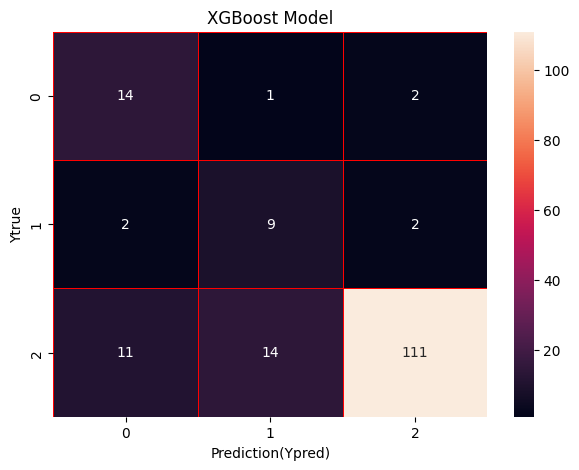





--- SVM ---
Accuracy: 0.8193
              precision    recall  f1-score   support

           0       0.50      0.35      0.41        17
           1       0.32      0.77      0.45        13
           2       0.98      0.88      0.93       136

    accuracy                           0.82       166
   macro avg       0.60      0.67      0.60       166
weighted avg       0.88      0.82      0.84       166



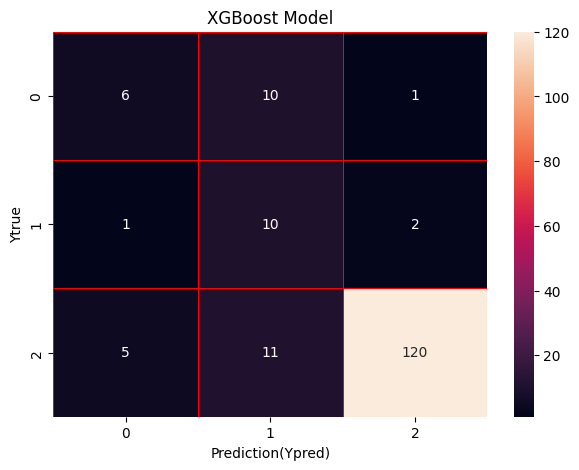





--- XGBoost ---
Accuracy: 0.9699
              precision    recall  f1-score   support

           0       0.89      0.94      0.91        17
           1       1.00      0.85      0.92        13
           2       0.98      0.99      0.98       136

    accuracy                           0.97       166
   macro avg       0.96      0.92      0.94       166
weighted avg       0.97      0.97      0.97       166



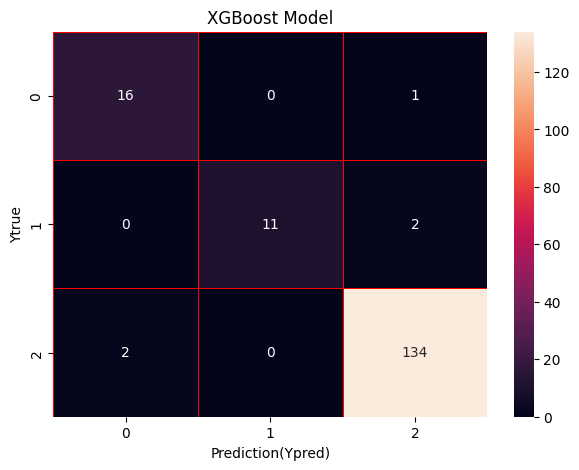

In [22]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    CM = confusion_matrix(y_test,y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    score.append(acc)
    f, ax = plt.subplots(figsize=(7,5))
    sns.heatmap(CM,annot = True, linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
    plt.title("XGBoost Model")
    plt.xlabel("Prediction(Ypred)")
    plt.ylabel("Ytrue")
    plt.show()
    print('\n'*3)

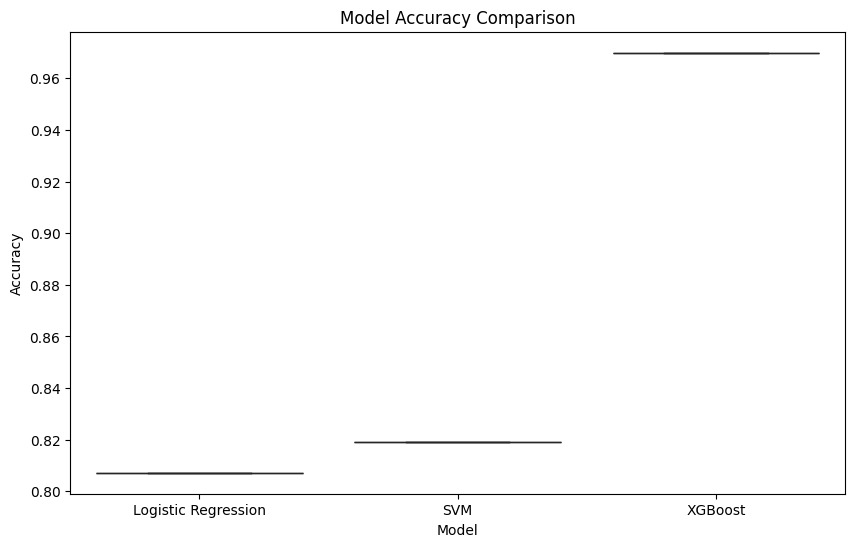

In [23]:
# plot scores

plt.figure(figsize=(10, 6))
models_list = list(models.keys())
sns.boxplot(x=models_list, y=score, palette='dark')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

In [24]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
XGB_pkl_filename = '/content/drive/MyDrive/Jobs/Mr Dayo/DIABETES PREDICTION/XGBoost_Diabetes_model.pkl'

# Open the file to save as pkl file
XGB_Model_pkl = open(XGB_pkl_filename, 'wb')
pickle.dump(model, XGB_Model_pkl)

# Close the pickle instances
XGB_Model_pkl.close()

In [26]:
import xgboost
print(xgboost.__version__)

3.2.0
